# Exercise 2 — Leapfrog Method

## Theory

The Leapfrog method is a numerical integration method commonly used to solve systems of ordinary differential equations describing dynamical systems. It is particularly useful for orbital problems because the position and velocity are updated at staggered time steps.

For the motion of a test body in a two-dimensional orbital plane, the position is given by

$$
\mathbf{r}=(x,y),
$$

and the gravitational acceleration produced by a central mass $M$ is

$$
\mathbf{a}
=
-\frac{GM}{r^3}\mathbf{r},
$$

where

$$
r^2=x^2+y^2.
$$

Therefore, the acceleration components are

$$
a_x=-\frac{GMx}{(x^2+y^2)^{3/2}},
$$

$$
a_y=-\frac{GMy}{(x^2+y^2)^{3/2}}.
$$

The state of the system can be represented by

$$
\mathbf{q}=
(x,y,v_x,v_y),
$$

where $v_x=dx/dt$ and $v_y=dy/dt$.

In the Leapfrog implementation, the velocities and positions are staggered in time. The velocity is first initialized using a half-step backwards:

$$
v_{x,0}=v_{x,0}-h\,a_x,
$$

$$
v_{y,0}=v_{y,0}-h\,a_y.
$$

The velocities are then updated according to

$$
v_{x,n+1}=v_{x,n}+2h\,a_x(x_n,y_n),
$$

$$
v_{y,n+1}=v_{y,n}+2h\,a_y(x_n,y_n).
$$

Using the updated velocities, the new positions are calculated as

$$
x_{n+1}=x_n+2h\,v_{x,n+1},
$$

$$
y_{n+1}=y_n+2h\,v_{y,n+1}.
$$

By repeating these steps, the numerical trajectory of the test body around the central mass can be obtained.

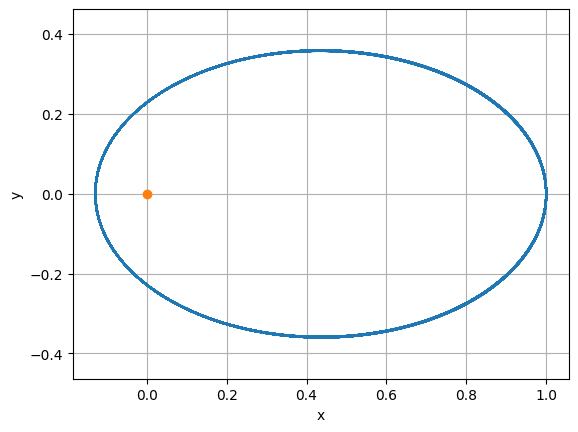

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parametros
G = 4*np.pi**2
M = 1

t_0 = 0
t_final = 20
n = 500000
h = (t_final-t_0)/n

# Tiempo
t = np.linspace(t_0,t_final,n)

# Posicion y velocidad
x = np.zeros(n)
y = np.zeros(n)
vx = np.zeros(n)
vy = np.zeros(n)

# Condiciones iniciales
x[0] = 1
y[0] = 0
vx[0] = 0
vy[0] = 3

# Aceleraciones
def ax(x,y):
  r2 = x**2 + y**2
  return -G*M*x/r2**(3/2)

def ay(x,y):
  r2 = x**2 + y**2
  return -G*M*y/r2**(3/2)

# Medio paso hacia atras para las velocidades
vx[0] = vx[0] - h*ax(x[0],y[0])
vy[0] = vy[0] - h*ay(x[0],y[0])

# Leapfrog
for i in range(n-1):

  vx[i+1] = vx[i] + 2*h*ax(x[i],y[i])
  vy[i+1] = vy[i] + 2*h*ay(x[i],y[i])

  x[i+1] = x[i] + 2*h*vx[i+1]
  y[i+1] = y[i] + 2*h*vy[i+1]

# Grafica
plt.plot(x,y)
plt.plot(0,0,'o')
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid()
plt.show()